In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("./dataset/household-income-analysis.csv")
# Read dataset
df.head()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210


In [3]:
# Check null value exists or not
df.isnull().sum()

Age                               0
Education_Level                   0
Occupation                        0
Number_of_Dependents              0
Location                          0
Work_Experience                   0
Marital_Status                    0
Employment_Status                 0
Household_Size                    0
Homeownership_Status              0
Type_of_Housing                   0
Gender                            0
Primary_Mode_of_Transportation    0
Income                            0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

In [5]:
# Check duplicates
df.duplicated().sum()

0

In [6]:
df.dtypes

Age                                int64
Education_Level                   object
Occupation                        object
Number_of_Dependents               int64
Location                          object
Work_Experience                    int64
Marital_Status                    object
Employment_Status                 object
Household_Size                     int64
Homeownership_Status              object
Type_of_Housing                   object
Gender                            object
Primary_Mode_of_Transportation    object
Income                             int64
dtype: object

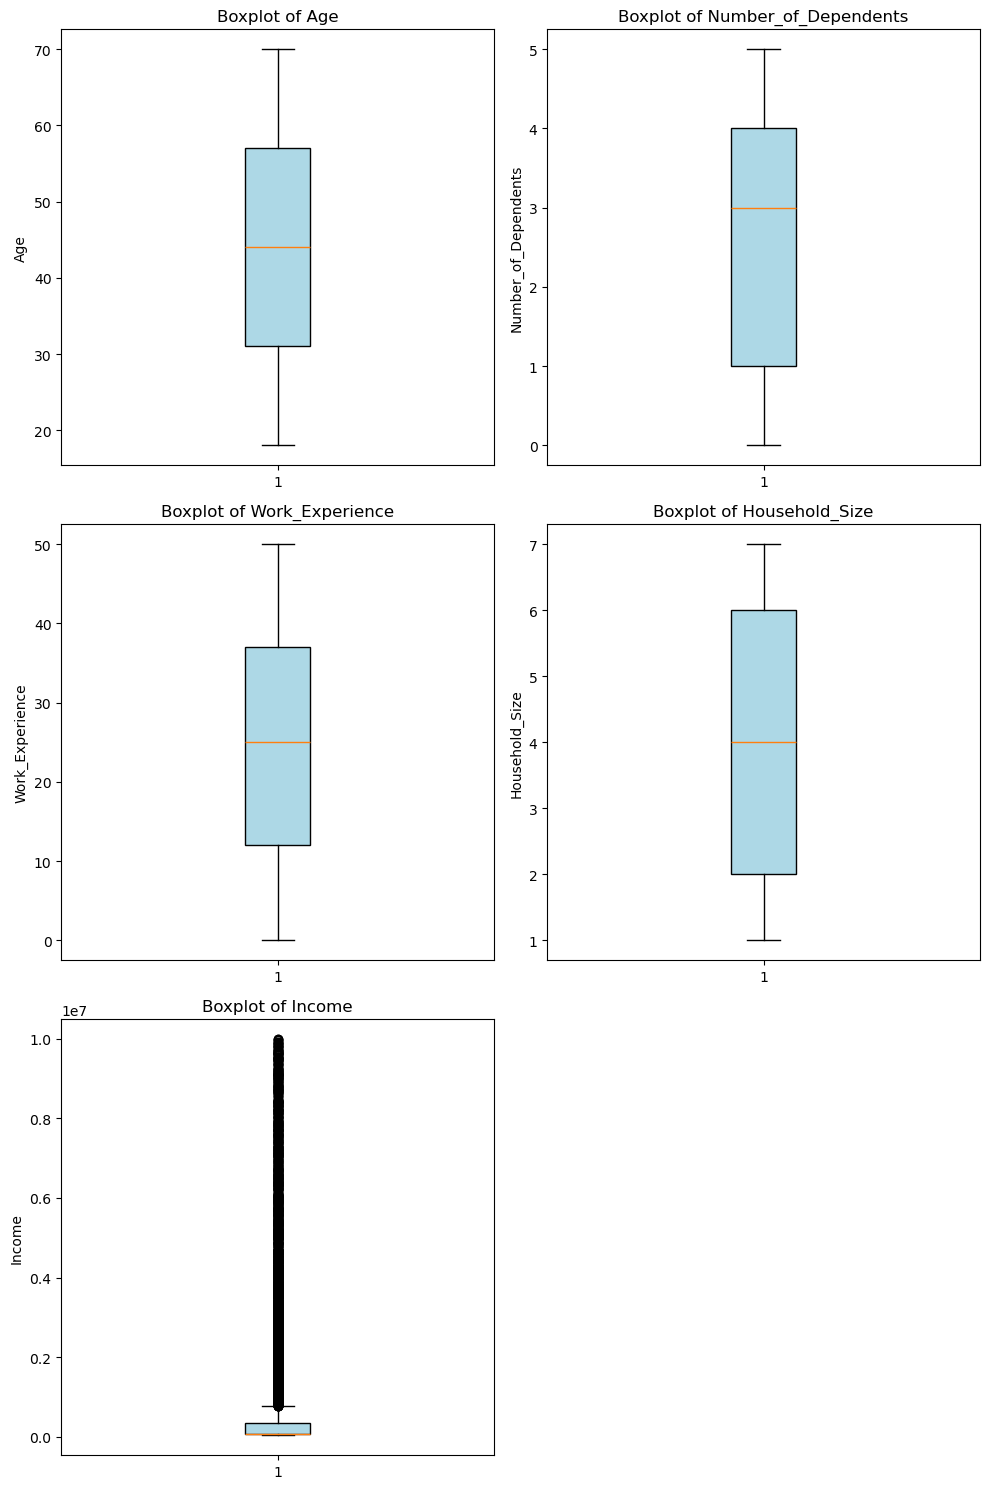

In [7]:
# Before outlier removal
numeric_cols = df.select_dtypes(include=[np.number]).columns
num_cols = len(numeric_cols)
num_rows = (num_cols + 1) // 2
fig, axes = plt.subplots(num_rows, 2, figsize=(10, 5 * num_rows))

axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Hide unused subplots (if odd number of columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Removes empty subplot spaces

plt.tight_layout()
plt.show()

In [8]:
# Remove outlier
# Compute Z-scores and filter without adding a new column
print(df.shape)
df = df[np.abs(stats.zscore(df['Income'])) < 3]
print(df.shape)

# correlation (heatmap), bar (categorcal), normalize (

(10000, 14)
(9626, 14)


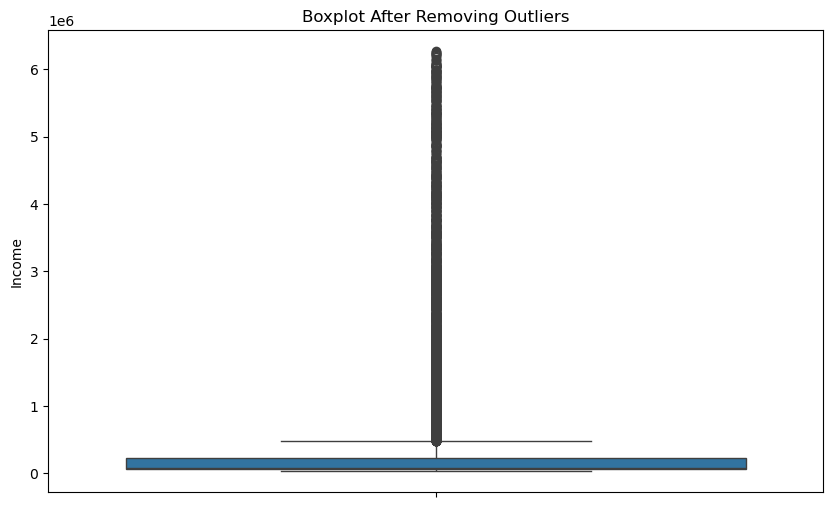

In [9]:
# After outlier removal
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Income'])
plt.title('Boxplot After Removing Outliers')
plt.show()

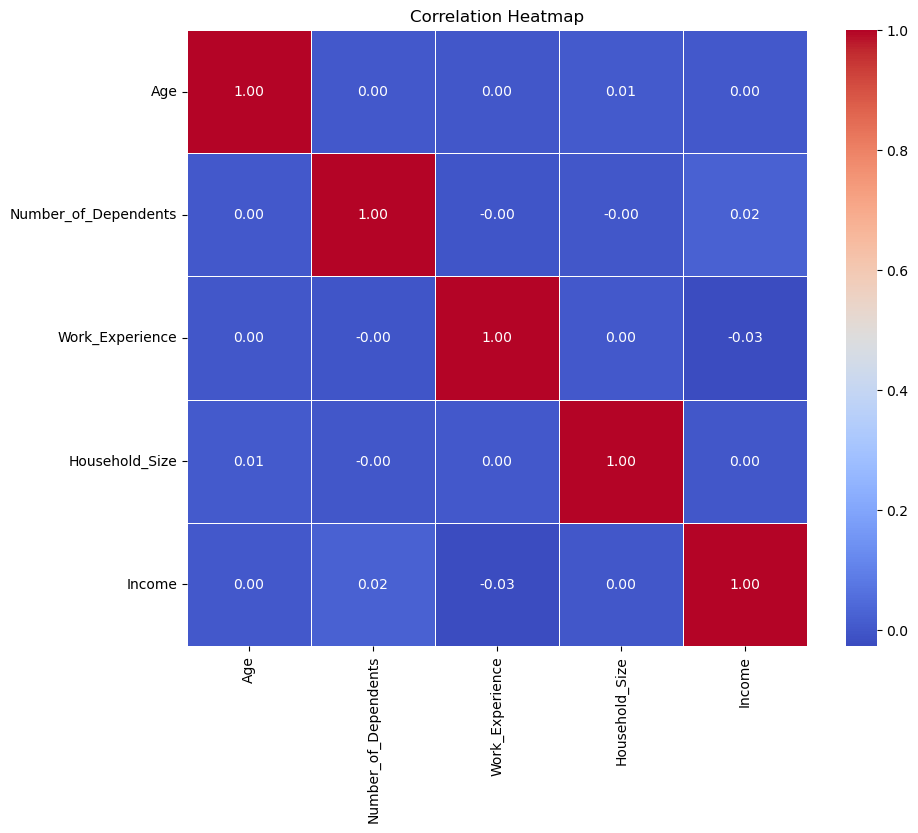

In [10]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

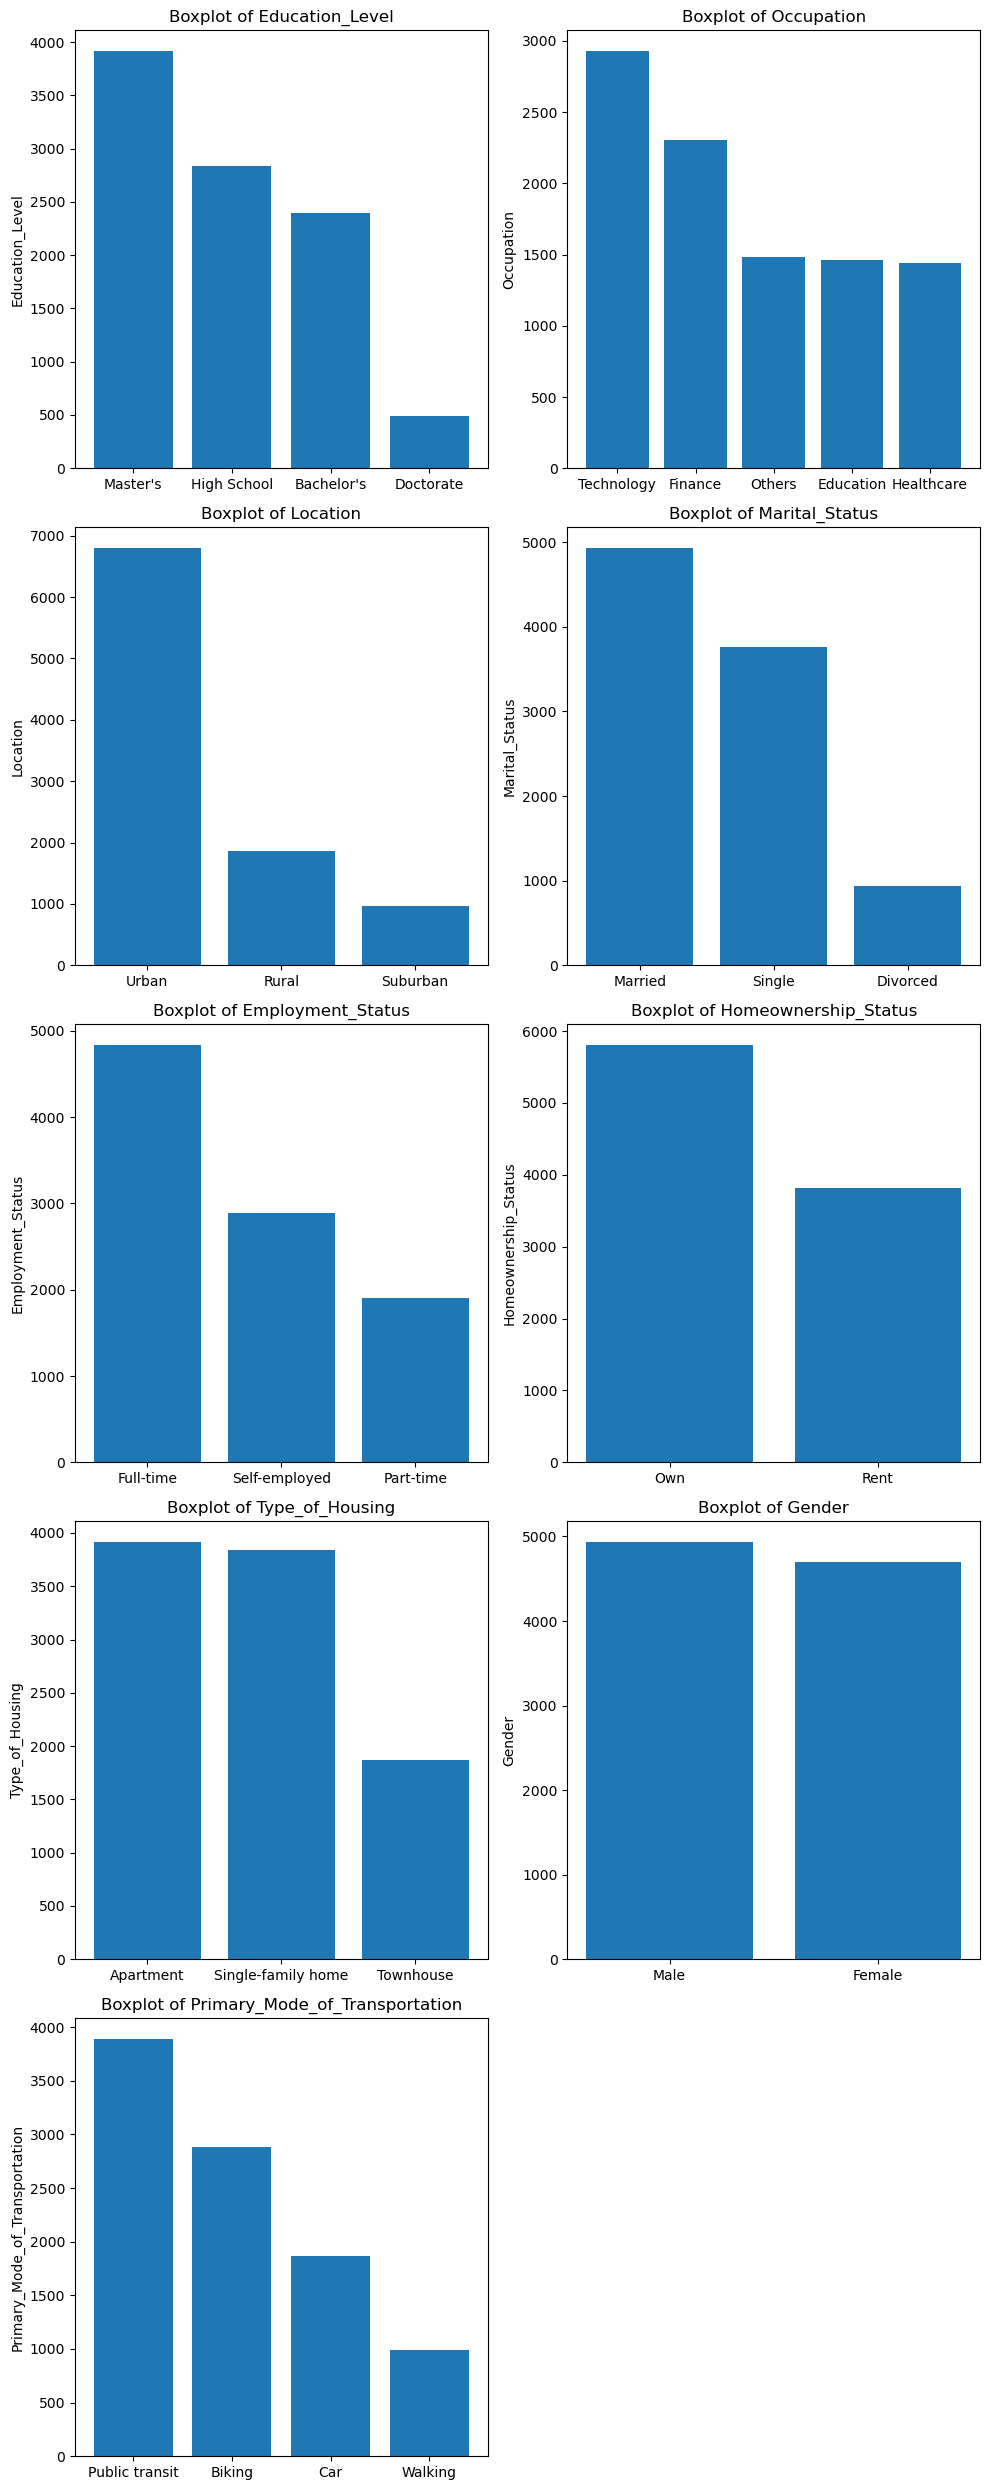

In [11]:
# Category plot
numeric_cols = df.select_dtypes(include=[np.object_]).columns
num_cols = len(numeric_cols)
num_rows = (num_cols + 1) // 2
fig, axes = plt.subplots(num_rows, 2, figsize=(10, 5 * num_rows))

axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(numeric_cols):
    axes[i].bar(df[col].unique(),df[col].value_counts().values)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Hide unused subplots (if odd number of columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Removes empty subplot spaces

plt.tight_layout()
plt.show()

In [12]:
# Normalize
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder

labelEncoder = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df[categorical_cols] = df[categorical_cols].apply(labelEncoder.fit_transform)

s = StandardScaler()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9626 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Age                             9626 non-null   int64
 1   Education_Level                 9626 non-null   int64
 2   Occupation                      9626 non-null   int64
 3   Number_of_Dependents            9626 non-null   int64
 4   Location                        9626 non-null   int64
 5   Work_Experience                 9626 non-null   int64
 6   Marital_Status                  9626 non-null   int64
 7   Employment_Status               9626 non-null   int64
 8   Household_Size                  9626 non-null   int64
 9   Homeownership_Status            9626 non-null   int64
 10  Type_of_Housing                 9626 non-null   int64
 11  Gender                          9626 non-null   int64
 12  Primary_Mode_of_Transportation  9626 non-null   int64
 13  Income  

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df.drop(columns='Income')
x_train, x_test, y_train, y_test = train_test_split(x,df['Income'], test_size=0.80,random_state=42)
linear = LinearRegression()
model = linear.fit(x_train, y_train)
pred = model.predict(x_test)

In [22]:
import pandas as pd
y= [40,50,50,70,65,65,80]
x1 = [100,200,300,400,500,600,700]
x2 = [10,20,10,30,20,20,30]
df = pd.DataFrame(y)
print(len(y),len(x1),len(x2))
df['x1'] = x1
df['x2'] = x2
df

7 7 7


,0,x1,x2
0,40,100,10
1,50,200,20
2,50,300,10
3,70,400,30
4,65,500,20
5,65,600,20
6,80,700,30


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(df[['x1','x2']],df[0], test_size=0.80,random_state=42)
linear = LinearRegression()
model = linear.fit(x_train, y_train)
pred = model.predict(x_test)